In [1]:
import re
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import numpy as np
import string

from collections import Counter
from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

## Task 1: Data Exploration and Preprocessing

In [3]:
articles_path = Path("articles.csv")

articles_raw = pd.read_csv(articles_path)
articles = articles_raw.copy()

print("Dataset shape:", articles.shape)
display(articles.head())

print("\nNull values per column:")
print(articles.isnull().sum())

Dataset shape: (2164, 2)


,doc_id,text
0,DOC_00001,"When I first saw this, I thought for a second ..."
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di..."
3,DOC_00004,Sjogren's syndrome has been known to induce dr...
4,DOC_00005,"Yes, I want to concentrate on other developmen..."



Null values per column:
doc_id    0
text      0
dtype: int64


In [4]:
articles["raw_word_count"] = articles["text"].apply(lambda x: len(str(x).split()))

print("Raw text length statistics:")
display(articles["raw_word_count"].describe())

Raw text length statistics:


count    2164.000000
mean      151.219039
std       228.399709
min        25.000000
25%        59.000000
50%        95.000000
75%       165.000000
max      6863.000000
Name: raw_word_count, dtype: float64

In [5]:
english_stopwords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    tokens = text.split()
    tokens = [token for token in tokens if token not in english_stopwords]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [stemmer.stem(token) for token in tokens]

    return " ".join(tokens)

In [6]:
articles["cleaned_text"] = articles["text"].apply(preprocess_text)

display(articles[["doc_id", "text", "cleaned_text"]].head())

,doc_id,text,cleaned_text
0,DOC_00001,"When I first saw this, I thought for a second ...",first saw thought second headlin star plier fo...
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...,difficulti high isp otv includ long transfer t...
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di...",forward neal ausman galileo mission director g...
3,DOC_00004,Sjogren's syndrome has been known to induce dr...,sjogren syndrom known induc dryness vagin tiss...
4,DOC_00005,"Yes, I want to concentrate on other developmen...",ye want concentr develop issu creat graphic li...


In [7]:
articles["cleaned_word_count"] = articles["cleaned_text"].apply(lambda x: len(str(x).split()))

preprocessing_summary = pd.DataFrame({
    "version": ["Raw text", "Cleaned text"],
    "avg_word_count": [
        articles["raw_word_count"].mean(),
        articles["cleaned_word_count"].mean()
    ],
    "std_word_count": [
        articles["raw_word_count"].std(),
        articles["cleaned_word_count"].std()
    ],
    "min_word_count": [
        articles["raw_word_count"].min(),
        articles["cleaned_word_count"].min()
    ],
    "max_word_count": [
        articles["raw_word_count"].max(),
        articles["cleaned_word_count"].max()
    ]
})

display(preprocessing_summary)

,version,avg_word_count,std_word_count,min_word_count,max_word_count
0,Raw text,151.219039,228.399709,25,6863
1,Cleaned text,83.882625,105.647903,10,1417


## Bag-of-Words and TF-IDF Representations

In [8]:
count_vectorizer = CountVectorizer(min_df=5, max_df=0.95)
bow_matrix = count_vectorizer.fit_transform(articles["cleaned_text"])

tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.95)
tfidf_matrix = tfidf_vectorizer.fit_transform(articles["cleaned_text"])

print("BoW matrix shape:", bow_matrix.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

BoW matrix shape: (2164, 3936)
TF-IDF matrix shape: (2164, 3936)


In [9]:
bow_df = pd.DataFrame(
    bow_matrix[:5, :10].toarray(),
    columns=count_vectorizer.get_feature_names_out()[:10]
)

tfidf_df = pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()[:10]
)

print("BoW matrix preview:")
display(bow_df)

print("TF-IDF matrix preview:")
display(tfidf_df)

BoW matrix preview:


,ab,abc,abil,abl,absolut,absorb,absurd,abus,ac,academ
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,3,0
3,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0


TF-IDF matrix preview:


,ab,abc,abil,abl,absolut,absorb,absurd,abus,ac,academ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.097695,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.187653,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [10]:
bow_vocabulary = count_vectorizer.get_feature_names_out()
term_frequencies = bow_matrix.sum(axis=0).A1

top_term_indices = term_frequencies.argsort()[::-1][:20]

top_bow_terms = pd.DataFrame({
    "term": bow_vocabulary[top_term_indices],
    "frequency": term_frequencies[top_term_indices].astype(int)
})

print("BoW vocabulary size:", len(bow_vocabulary))
display(top_bow_terms)

BoW vocabulary size: 3936


,term,frequency
0,offer,1189
1,would,1152
2,deal,981
3,one,918
4,pickup,897
5,use,877
6,get,863
7,like,839
8,sale,764
9,fast,762


In [11]:
# Representative Words per Document (TF-IDF)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

def get_top_tfidf_words_per_doc(tfidf_matrix, feature_names, top_n=5):
    top_words_per_doc = []

    for i in range(tfidf_matrix.shape[0]):
        row = tfidf_matrix[i].toarray().flatten()
        top_indices = row.argsort()[::-1][:top_n]
        top_words = [feature_names[j] for j in top_indices if row[j] > 0]
        top_words_per_doc.append(top_words)

    return top_words_per_doc

articles["top_tfidf_words"] = get_top_tfidf_words_per_doc(
    tfidf_matrix,
    tfidf_feature_names,
    top_n=5
)

display(articles[["doc_id", "top_tfidf_words"]].head())

,doc_id,top_tfidf_words
0,DOC_00001,"[mcwilliam, msu, circumfer, srb, cl]"
1,DOC_00002,"[radiat, high, sourc, nuclear, array]"
2,DOC_00003,"[april, telemetri, test, data, bp]"
3,DOC_00004,"[induc, known, josh, vm, enlarg]"
4,DOC_00005,"[concentr, grade, request, mac, consum]"


In [12]:
all_top_tfidf_words = [
    word
    for doc_words in articles["top_tfidf_words"]
    for word in doc_words
]

top_global_tfidf_words = pd.DataFrame(
    Counter(all_top_tfidf_words).most_common(20),
    columns=["term", "document_count_as_top_word"]
)

print("Top TF-IDF words across documents:")
display(top_global_tfidf_words)

Top TF-IDF words across documents:


,term,document_count_as_top_word
0,car,59
1,space,47
2,game,45
3,play,35
4,offer,33
5,team,33
6,hockey,30
7,file,28
8,player,27
9,imag,27


In [13]:
print("Articles dataset ready for clustering:", articles.shape)

display(
    articles[["doc_id", "text", "cleaned_text", "top_tfidf_words"]].head()
)

Articles dataset ready for clustering: (2164, 6)


,doc_id,text,cleaned_text,top_tfidf_words
0,DOC_00001,"When I first saw this, I thought for a second ...",first saw thought second headlin star plier fo...,"[mcwilliam, msu, circumfer, srb, cl]"
1,DOC_00002,The difficulties of a high Isp OTV include: Lo...,difficulti high isp otv includ long transfer t...,"[radiat, high, sourc, nuclear, array]"
2,DOC_00003,"Forwarded from Neal Ausman, Galileo Mission Di...",forward neal ausman galileo mission director g...,"[april, telemetri, test, data, bp]"
3,DOC_00004,Sjogren's syndrome has been known to induce dr...,sjogren syndrom known induc dryness vagin tiss...,"[induc, known, josh, vm, enlarg]"
4,DOC_00005,"Yes, I want to concentrate on other developmen...",ye want concentr develop issu creat graphic li...,"[concentr, grade, request, mac, consum]"


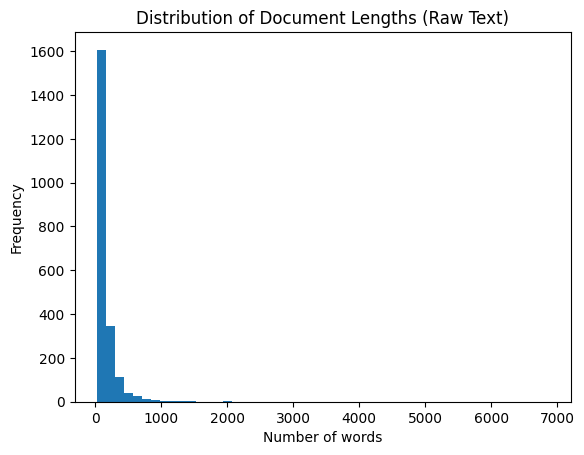

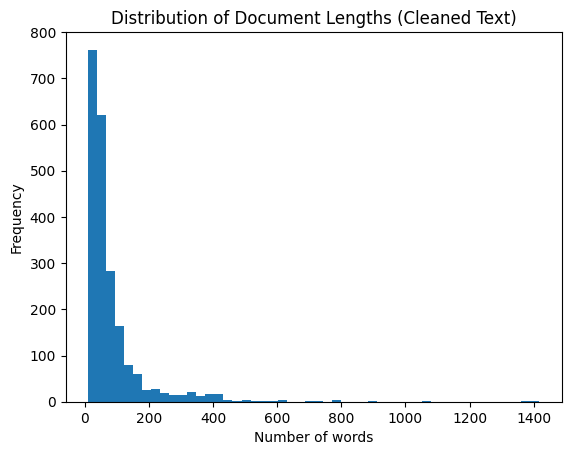

In [14]:
plt.figure()
plt.hist(articles["raw_word_count"], bins=50)
plt.title("Distribution of Document Lengths (Raw Text)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(articles["cleaned_word_count"], bins=50)
plt.title("Distribution of Document Lengths (Cleaned Text)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

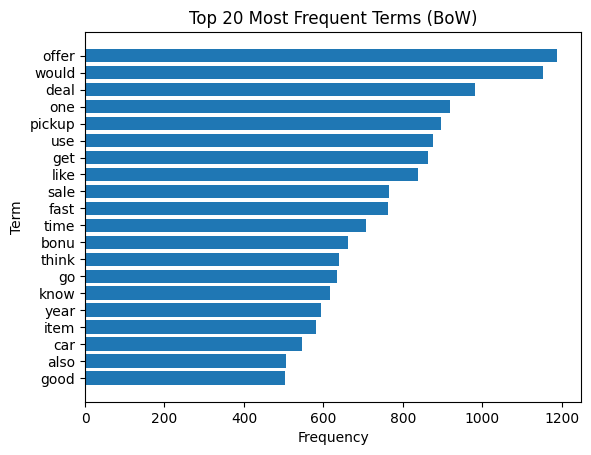

In [15]:
top_bow_terms_plot = top_bow_terms.sort_values(by="frequency", ascending=True)

plt.figure()
plt.barh(top_bow_terms_plot["term"], top_bow_terms_plot["frequency"])
plt.title("Top 20 Most Frequent Terms (BoW)")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.show()

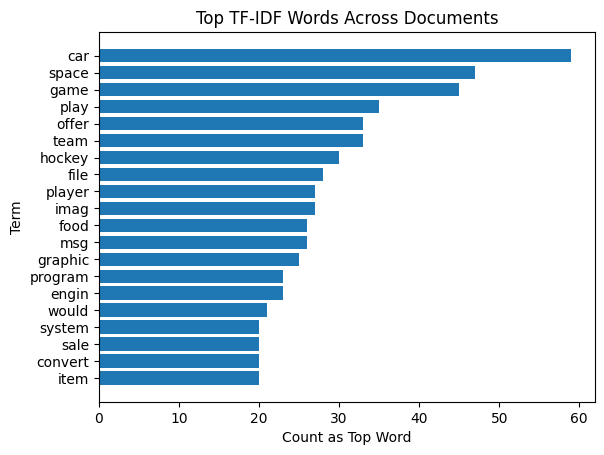

In [16]:
top_tfidf_plot = top_global_tfidf_words.sort_values(
    by="document_count_as_top_word",
    ascending=True
)

plt.figure()
plt.barh(
    top_tfidf_plot["term"],
    top_tfidf_plot["document_count_as_top_word"]
)
plt.title("Top TF-IDF Words Across Documents")
plt.xlabel("Count as Top Word")
plt.ylabel("Term")
plt.show()

## Task 2: Clustering

In [17]:
def summarize_clusters(articles, labels_column, matrix, vectorizer, top_n=10):
    feature_names = vectorizer.get_feature_names_out()

    print("Cluster sizes:")
    display(articles[labels_column].value_counts().sort_index())

    for cluster_id in sorted(articles[labels_column].unique()):
        print(f"\nCluster {cluster_id}")

        cluster_mask = articles[labels_column] == cluster_id
        positions = np.where(cluster_mask.to_numpy())[0]

        cluster_mean = matrix[positions].mean(axis=0)
        cluster_mean = np.asarray(cluster_mean).ravel()

        top_indices = cluster_mean.argsort()[::-1][:top_n]
        top_words = [feature_names[i] for i in top_indices]

        print("Top words:", ", ".join(top_words))
        print("Size:", len(positions))

In [18]:
def plot_clusters_2d(matrix, labels, title):
    svd = TruncatedSVD(n_components=2, random_state=42)
    points = svd.fit_transform(matrix)

    plot_data = pd.DataFrame({
        "x": points[:, 0],
        "y": points[:, 1],
        "cluster": labels.astype(str)
    })

    plt.figure(figsize=(10, 7))

    for cluster_id, cluster_data in plot_data.groupby("cluster"):
        plt.scatter(
            cluster_data["x"],
            cluster_data["y"],
            s=18,
            alpha=0.65,
            label=f"Cluster {cluster_id}"
        )

    plt.title(title)
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    print("Explained variance in 2D projection:", svd.explained_variance_ratio_.sum().round(4))

In [19]:
n_clusters = 10
n_init = 10

### K-Means with Bag-of-Words

Cluster sizes:


cluster_bow
0     127
1      11
2       1
3      17
4      16
5       1
6       1
7       6
8    1983
9       1
Name: count, dtype: int64


Cluster 0
Top words: would, one, get, time, use, like, think, year, space, team
Size: 127

Cluster 1
Top words: pickup, deal, fast, limit, offer, discount, cash, special, quick, exclus
Size: 11

Cluster 2
Top words: op, col, row, int, imag, valu, input, fp, magnitud, mag
Size: 1

Cluster 3
Top words: offer, coupon, item, http, deal, ref, sale, bundl, pickup, clearanc
Size: 17

Cluster 4
Top words: list, offer, deal, bonu, sale, promo, buy, fast, code, click
Size: 16

Cluster 5
Top words: sj, bo, tb, buf, nyr, mon, har, la, cal, edm
Size: 1

Cluster 6
Top words: flyer, sabr, puck, play, goal, soderstrom, get, th, back, right
Size: 1

Cluster 7
Top words: pickup, bonu, sale, cash, quick, discount, offer, deal, special, fast
Size: 6

Cluster 8
Top words: would, one, like, use, get, know, car, go, think, time
Size: 1983

Cluster 9
Top words: water, dept, citi, system, co, new, boston, protect, divis, contamin
Size: 1


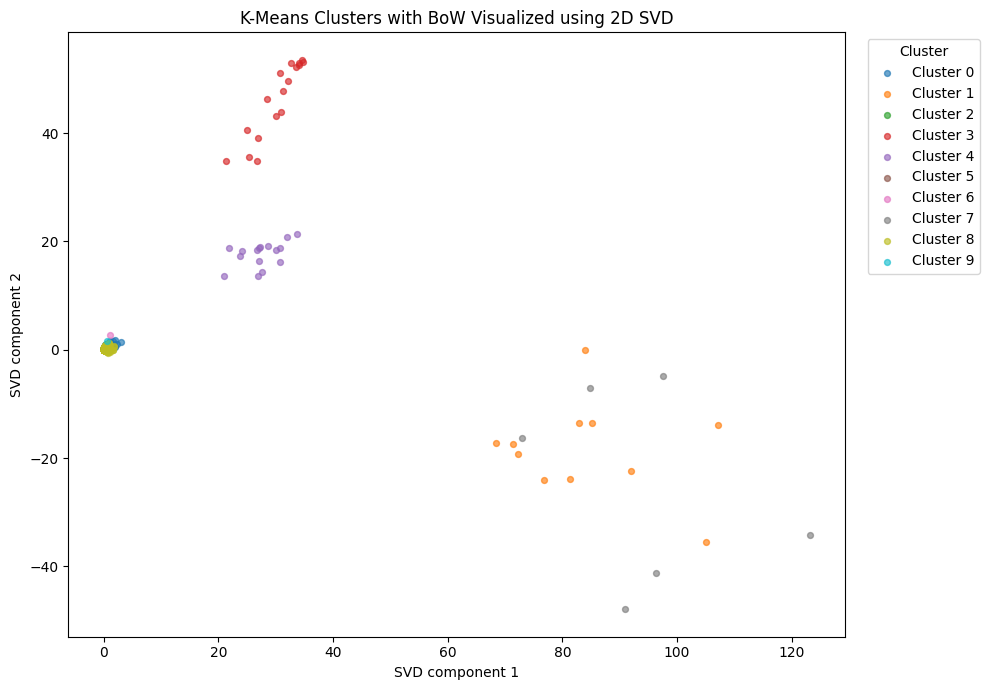

Explained variance in 2D projection: 0.34


In [20]:
kmeans_bow = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init)
articles["cluster_bow"] = kmeans_bow.fit_predict(bow_matrix)

summarize_clusters(
    articles=articles,
    labels_column="cluster_bow",
    matrix=bow_matrix,
    vectorizer=count_vectorizer
)

plot_clusters_2d(
    bow_matrix,
    articles["cluster_bow"],
    "K-Means Clusters with BoW Visualized using 2D SVD"
)

### K-Means with TF-IDF

Cluster sizes:


cluster_tfidf
0     17
1    249
2    953
3    295
4     36
5     70
6     89
7    151
8     33
9    271
Name: count, dtype: int64


Cluster 0
Top words: http, coupon, offer, item, ref, deal, sale, bundl, clearanc, trust
Size: 17

Cluster 1
Top words: space, nasa, launch, orbit, fund, would, moon, scienc, shuttl, think
Size: 249

Cluster 2
Top words: car, one, like, get, know, would, use, time, think, problem
Size: 953

Cluster 3
Top words: file, graphic, imag, program, thank, use, format, help, window, look
Size: 295

Cluster 4
Top words: msg, food, chines, restaur, reaction, peopl, glutam, caus, studi, tast
Size: 36

Cluster 5
Top words: cadr, dsl, jxp, chastiti, surrend, intellect, geb, skeptic, shame, gordon
Size: 70

Cluster 6
Top words: play, player, hockey, team, nhl, game, leagu, canadian, european, would
Size: 89

Cluster 7
Top words: would, go, get, like, mine, right, idea, year, let, moon
Size: 151

Cluster 8
Top words: bonu, offer, pickup, deal, sale, fast, cash, promo, list, discount
Size: 33

Cluster 9
Top words: game, team, win, season, go, playoff, leaf, hockey, year, play
Size: 271


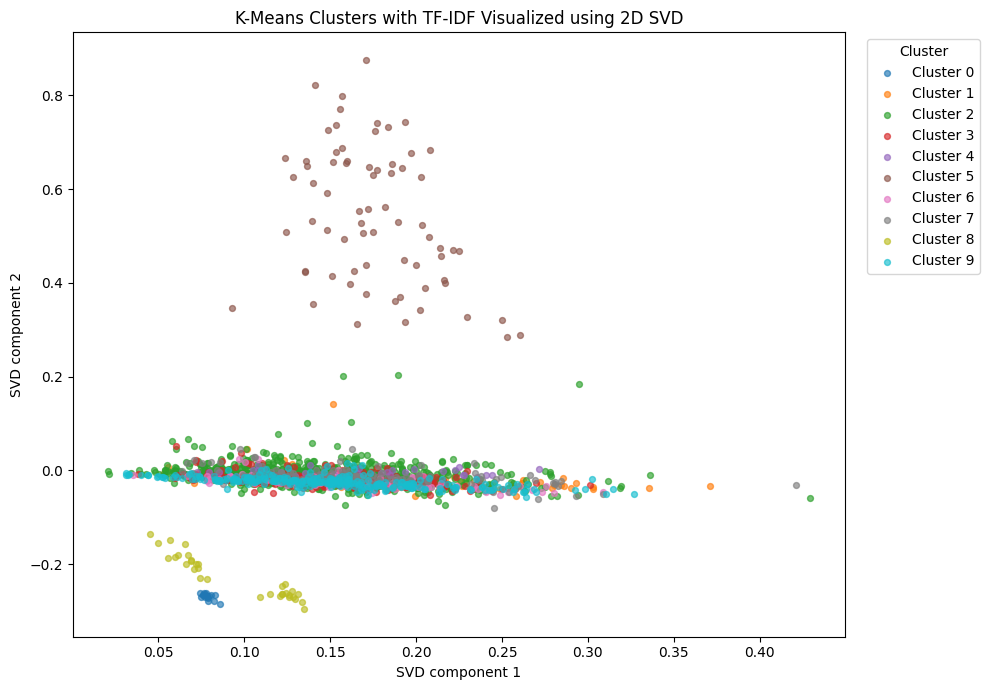

Explained variance in 2D projection: 0.0152


In [21]:
kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init)
articles["cluster_tfidf"] = kmeans_tfidf.fit_predict(tfidf_matrix)

summarize_clusters(
    articles=articles,
    labels_column="cluster_tfidf",
    matrix=tfidf_matrix,
    vectorizer=tfidf_vectorizer
)

plot_clusters_2d(
    tfidf_matrix,
    articles["cluster_tfidf"],
    "K-Means Clusters with TF-IDF Visualized using 2D SVD"
)

### Hierarchical Clustering with Bag-of-Words

Cluster sizes:


cluster_bow_hierarchical
0    2073
1      16
2       4
3       6
4       4
5       3
6       2
7       1
8       3
9      52
Name: count, dtype: int64


Cluster 0
Top words: would, one, get, like, use, time, think, go, know, year
Size: 2073

Cluster 1
Top words: center, nasa, rec, auto, gov, team, univers, site, larc, met
Size: 16

Cluster 2
Top words: op, col, row, de, van, int, imag, valu, input, fp
Size: 4

Cluster 3
Top words: treat, see, syndrom, dyer, work, thank, yeah, known, must, definit
Size: 6

Cluster 4
Top words: lemieux, devil, rough, pittsburgh, steven, nj, penalti, jet, bee, flyer
Size: 4

Cluster 5
Top words: normal, perhap, shell, break, state, origin, intestin, loss, say, pass
Size: 3

Cluster 6
Top words: plug, mi, replac, less, drain, someon, much, oil, lock, greatest
Size: 2

Cluster 7
Top words: receiv, site, sake, pop, okay, request, sooner, whole, movi, mail
Size: 1

Cluster 8
Top words: german, born, forward, player, germani, canada, averag, site, fact, moment
Size: 3

Cluster 9
Top words: offer, pickup, deal, sale, fast, bonu, item, cash, coupon, discount
Size: 52


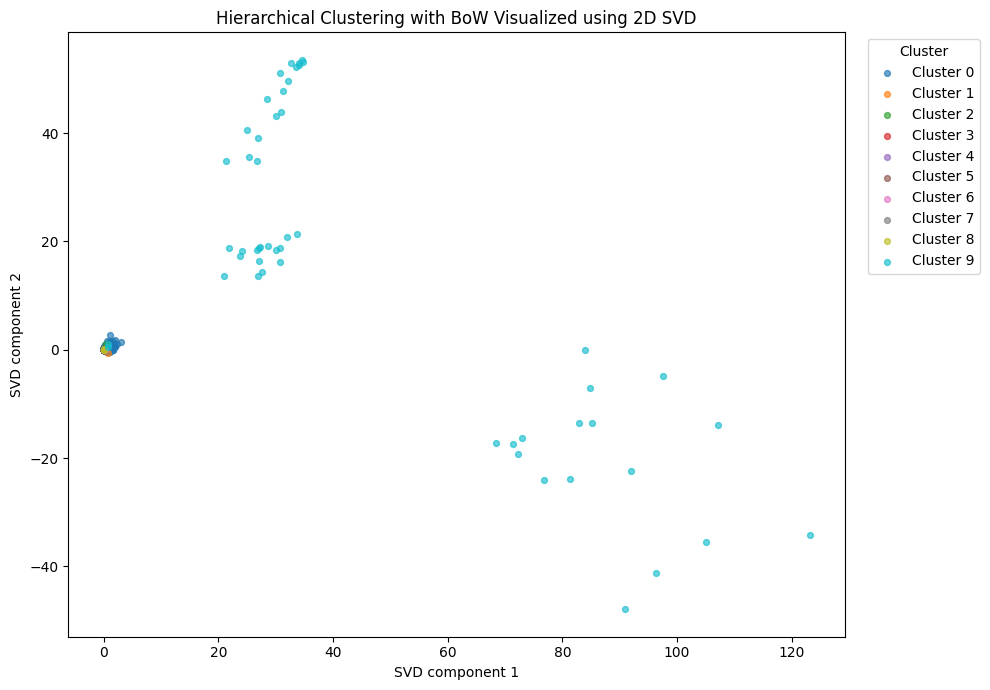

Explained variance in 2D projection: 0.34


In [22]:
hierarchical_bow = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="cosine",
    linkage="average"
)

articles["cluster_bow_hierarchical"] = hierarchical_bow.fit_predict(
    bow_matrix.toarray()
)

summarize_clusters(
    articles=articles,
    labels_column="cluster_bow_hierarchical",
    matrix=bow_matrix,
    vectorizer=count_vectorizer
)

plot_clusters_2d(
    bow_matrix,
    articles["cluster_bow_hierarchical"],
    "Hierarchical Clustering with BoW Visualized using 2D SVD"
)

### Hierarchical Clustering with TF-IDF

Cluster sizes:


cluster_tfidf_hierarchical
0     426
1    1613
2       8
3      21
4      20
5       2
6      11
7      50
8       9
9       4
Name: count, dtype: int64


Cluster 0
Top words: game, team, play, player, hockey, go, would, year, season, win
Size: 426

Cluster 1
Top words: would, car, use, like, one, get, know, think, look, space
Size: 1613

Cluster 2
Top words: mazda, motorola, far, cultur, paperwork, nissan, somewher, partner, lineup, variat
Size: 8

Cluster 3
Top words: jupit, gehrel, tom, radiu, nick, sq, mcwilliam, msu, circumfer, comet
Size: 21

Cluster 4
Top words: acceler, air, wing, tube, aluminum, plane, somebodi, control, solid, test
Size: 20

Cluster 5
Top words: col, op, row, hp, se, sold, int, valu, sell, com
Size: 2

Cluster 6
Top words: needl, inflat, balloon, deflat, practition, inject, resist, case, aid, sec
Size: 11

Cluster 7
Top words: offer, item, deal, pickup, sale, bonu, coupon, http, fast, ref
Size: 50

Cluster 8
Top words: woman, pocket, cloth, endometriosi, transport, men, would, appear, virtual, oper
Size: 9

Cluster 9
Top words: warrant, perhap, intestin, normal, chang, state, origin, default, differ, paramet
S

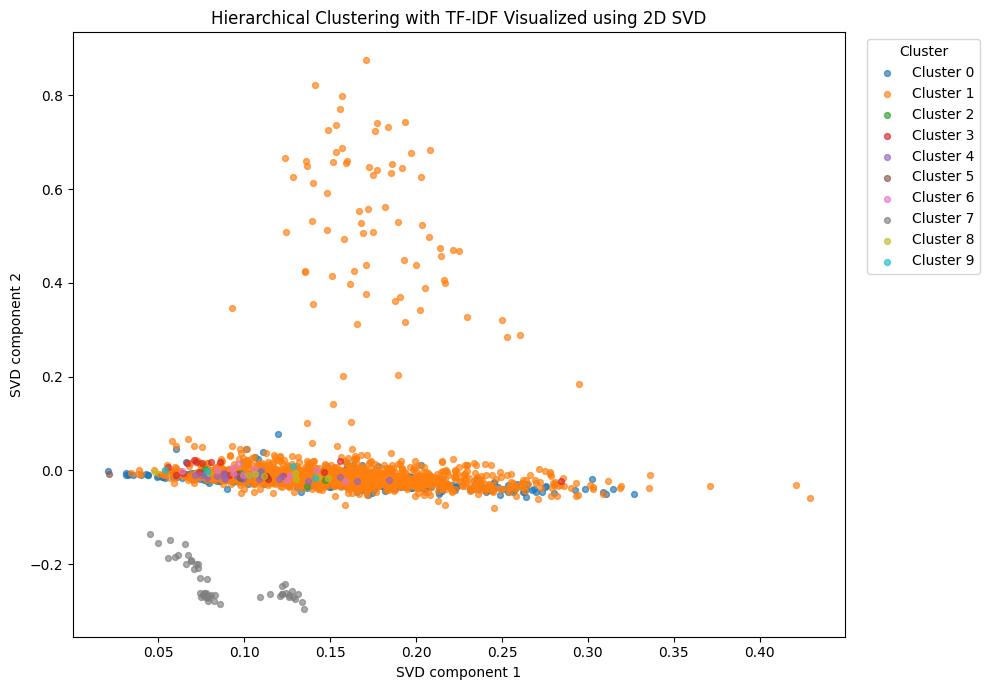

Explained variance in 2D projection: 0.0152


In [23]:
hierarchical_tfidf = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="cosine",
    linkage="average"
)

articles["cluster_tfidf_hierarchical"] = hierarchical_tfidf.fit_predict(
    tfidf_matrix.toarray()
)

summarize_clusters(
    articles=articles,
    labels_column="cluster_tfidf_hierarchical",
    matrix=tfidf_matrix,
    vectorizer=tfidf_vectorizer
)

plot_clusters_2d(
    tfidf_matrix,
    articles["cluster_tfidf_hierarchical"],
    "Hierarchical Clustering with TF-IDF Visualized using 2D SVD"
)

### Comparison of Clustering Outputs

In [24]:
cluster_size_comparison = pd.DataFrame({
    "kmeans_bow": articles["cluster_bow"].value_counts().sort_index(),
    "kmeans_tfidf": articles["cluster_tfidf"].value_counts().sort_index(),
    "hierarchical_bow": articles["cluster_bow_hierarchical"].value_counts().sort_index(),
    "hierarchical_tfidf": articles["cluster_tfidf_hierarchical"].value_counts().sort_index()
})

display(cluster_size_comparison)

,kmeans_bow,kmeans_tfidf,hierarchical_bow,hierarchical_tfidf
0,127,17,2073,426
1,11,249,16,1613
2,1,953,4,8
3,17,295,6,21
4,16,36,4,20
5,1,70,3,2
6,1,89,2,11
7,6,151,1,50
8,1983,33,3,9
9,1,271,52,4


In [25]:
silhouette_results = pd.DataFrame([
    {
        "model": "K-Means + BoW",
        "representation": "BoW",
        "algorithm": "K-Means",
        "silhouette_score": silhouette_score(
            bow_matrix,
            articles["cluster_bow"],
            metric="cosine"
        )
    },
    {
        "model": "K-Means + TF-IDF",
        "representation": "TF-IDF",
        "algorithm": "K-Means",
        "silhouette_score": silhouette_score(
            tfidf_matrix,
            articles["cluster_tfidf"],
            metric="cosine"
        )
    },
    {
        "model": "Hierarchical + BoW",
        "representation": "BoW",
        "algorithm": "Hierarchical",
        "silhouette_score": silhouette_score(
            bow_matrix,
            articles["cluster_bow_hierarchical"],
            metric="cosine"
        )
    },
    {
        "model": "Hierarchical + TF-IDF",
        "representation": "TF-IDF",
        "algorithm": "Hierarchical",
        "silhouette_score": silhouette_score(
            tfidf_matrix,
            articles["cluster_tfidf_hierarchical"],
            metric="cosine"
        )
    }
])

silhouette_results = silhouette_results.sort_values(
    "silhouette_score",
    ascending=False
).reset_index(drop=True)

display(silhouette_results)

,model,representation,algorithm,silhouette_score
0,K-Means + TF-IDF,TF-IDF,K-Means,0.030446
1,Hierarchical + TF-IDF,TF-IDF,Hierarchical,0.013873
2,Hierarchical + BoW,BoW,Hierarchical,0.008694
3,K-Means + BoW,BoW,K-Means,-0.027876


### Testing Different Numbers of Clusters Across All Models

In [26]:
k_values = range(2, 11)
comparison_k_results = []

for k in k_values:
    print(f"Running k={k}")

    kmeans_bow = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans_bow = kmeans_bow.fit_predict(bow_matrix)

    comparison_k_results.append({
        "model": "K-Means + BoW",
        "k": k,
        "silhouette_score": silhouette_score(
            bow_matrix,
            labels_kmeans_bow,
            metric="cosine"
        )
    })

    kmeans_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans_tfidf = kmeans_tfidf.fit_predict(tfidf_matrix)

    comparison_k_results.append({
        "model": "K-Means + TF-IDF",
        "k": k,
        "silhouette_score": silhouette_score(
            tfidf_matrix,
            labels_kmeans_tfidf,
            metric="cosine"
        )
    })

    hierarchical_bow = AgglomerativeClustering(
        n_clusters=k,
        metric="cosine",
        linkage="average"
    )
    labels_hierarchical_bow = hierarchical_bow.fit_predict(
        bow_matrix.toarray()
    )

    comparison_k_results.append({
        "model": "Hierarchical + BoW",
        "k": k,
        "silhouette_score": silhouette_score(
            bow_matrix,
            labels_hierarchical_bow,
            metric="cosine"
        )
    })

    hierarchical_tfidf = AgglomerativeClustering(
        n_clusters=k,
        metric="cosine",
        linkage="average"
    )
    labels_hierarchical_tfidf = hierarchical_tfidf.fit_predict(
        tfidf_matrix.toarray()
    )

    comparison_k_results.append({
        "model": "Hierarchical + TF-IDF",
        "k": k,
        "silhouette_score": silhouette_score(
            tfidf_matrix,
            labels_hierarchical_tfidf,
            metric="cosine"
        )
    })

comparison_k_results = pd.DataFrame(comparison_k_results)

display(
    comparison_k_results.sort_values(
        "silhouette_score",
        ascending=False
    ).reset_index(drop=True)
)

Running k=2
Running k=3
Running k=4
Running k=5
Running k=6
Running k=7
Running k=8
Running k=9
Running k=10


,model,k,silhouette_score
0,Hierarchical + BoW,2,0.041075
1,K-Means + BoW,3,0.038947
2,K-Means + TF-IDF,8,0.035881
3,K-Means + BoW,5,0.035463
4,K-Means + BoW,4,0.035379
5,K-Means + TF-IDF,7,0.034930
6,K-Means + BoW,2,0.034205
7,Hierarchical + BoW,3,0.034144
8,K-Means + TF-IDF,6,0.033735
9,K-Means + TF-IDF,9,0.033027


In [27]:
best_by_model = (
    comparison_k_results
    .sort_values("silhouette_score", ascending=False)
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(best_by_model)

,model,k,silhouette_score
0,Hierarchical + BoW,2,0.041075
1,K-Means + BoW,3,0.038947
2,K-Means + TF-IDF,8,0.035881
3,Hierarchical + TF-IDF,2,0.025623


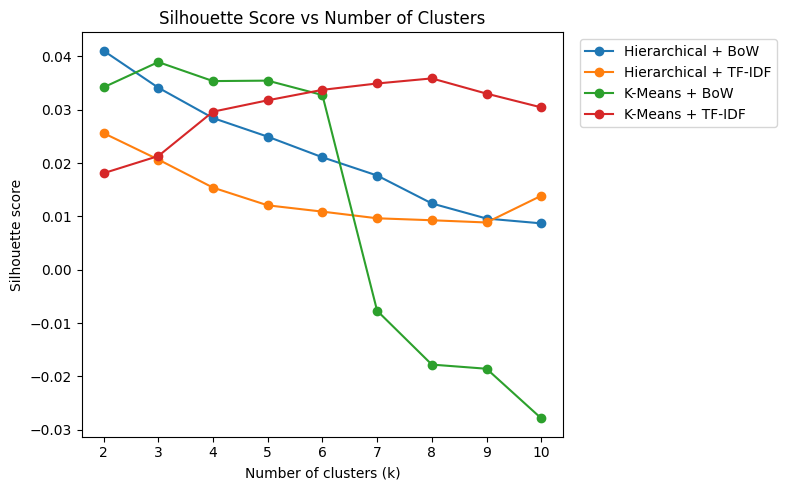

In [28]:
plt.figure(figsize=(8, 5))

for model_name, model_data in comparison_k_results.groupby("model"):
    model_data = model_data.sort_values("k")
    plt.plot(
        model_data["k"],
        model_data["silhouette_score"],
        marker="o",
        label=model_name
    )

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Fine-Tuning K-Means with TF-IDF

In [29]:
k_values = range(2, 11)
n_init_values = [5, 10, 15, 20, 25]

k_ninit_results = []

for k in k_values:
    for n_init in n_init_values:
        print(f"Running k={k}, n_init={n_init}")

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=n_init
        )

        labels = model.fit_predict(tfidf_matrix)

        score = silhouette_score(
            tfidf_matrix,
            labels,
            metric="cosine"
        )

        k_ninit_results.append({
            "model": "K-Means + TF-IDF",
            "k": k,
            "n_init": n_init,
            "silhouette_score": score
        })

k_ninit_results = pd.DataFrame(k_ninit_results)

display(
    k_ninit_results.sort_values(
        "silhouette_score",
        ascending=False
    ).reset_index(drop=True)
)

Running k=2, n_init=5
Running k=2, n_init=10
Running k=2, n_init=15
Running k=2, n_init=20
Running k=2, n_init=25
Running k=3, n_init=5
Running k=3, n_init=10
Running k=3, n_init=15
Running k=3, n_init=20
Running k=3, n_init=25
Running k=4, n_init=5
Running k=4, n_init=10
Running k=4, n_init=15
Running k=4, n_init=20
Running k=4, n_init=25
Running k=5, n_init=5
Running k=5, n_init=10
Running k=5, n_init=15
Running k=5, n_init=20
Running k=5, n_init=25
Running k=6, n_init=5
Running k=6, n_init=10
Running k=6, n_init=15
Running k=6, n_init=20
Running k=6, n_init=25
Running k=7, n_init=5
Running k=7, n_init=10
Running k=7, n_init=15
Running k=7, n_init=20
Running k=7, n_init=25
Running k=8, n_init=5
Running k=8, n_init=10
Running k=8, n_init=15
Running k=8, n_init=20
Running k=8, n_init=25
Running k=9, n_init=5
Running k=9, n_init=10
Running k=9, n_init=15
Running k=9, n_init=20
Running k=9, n_init=25
Running k=10, n_init=5
Running k=10, n_init=10
Running k=10, n_init=15
Running k=10, n_i

,model,k,n_init,silhouette_score
0,K-Means + TF-IDF,8,10,0.035881
1,K-Means + TF-IDF,8,5,0.035881
2,K-Means + TF-IDF,9,20,0.035411
3,K-Means + TF-IDF,9,15,0.035411
4,K-Means + TF-IDF,7,15,0.034930
5,K-Means + TF-IDF,7,10,0.034930
6,K-Means + TF-IDF,7,5,0.034930
7,K-Means + TF-IDF,8,25,0.034792
8,K-Means + TF-IDF,8,20,0.034792
9,K-Means + TF-IDF,8,15,0.034792


In [30]:
best_kmeans_tfidf = k_ninit_results.loc[
    k_ninit_results["silhouette_score"].idxmax()
]

display(best_kmeans_tfidf)

model               K-Means + TF-IDF
k                                  8
n_init                             5
silhouette_score            0.035881
Name: 30, dtype: object

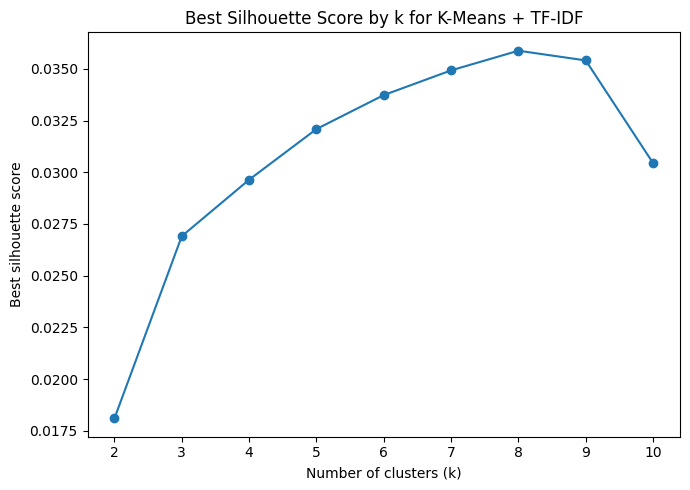

In [31]:
plot_df = (
    k_ninit_results
    .groupby("k")["silhouette_score"]
    .max()
    .reset_index()
)

plt.figure(figsize=(7, 5))
plt.plot(
    plot_df["k"],
    plot_df["silhouette_score"],
    marker="o"
)
plt.title("Best Silhouette Score by k for K-Means + TF-IDF")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Best silhouette score")
plt.tight_layout()
plt.show()

### Final Optimized K-Means with TF-IDF

In [32]:
final_k = 8
final_n_init = 10

final_kmeans_tfidf = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=final_n_init
)

articles["cluster_tfidf_final"] = final_kmeans_tfidf.fit_predict(tfidf_matrix)

final_silhouette = silhouette_score(
    tfidf_matrix,
    articles["cluster_tfidf_final"],
    metric="cosine"
)

print("Final model: K-Means + TF-IDF")
print("k:", final_k)
print("n_init:", final_n_init)
print("silhouette score:", final_silhouette)

Final model: K-Means + TF-IDF
k: 8
n_init: 10
silhouette score: 0.03588104131932791


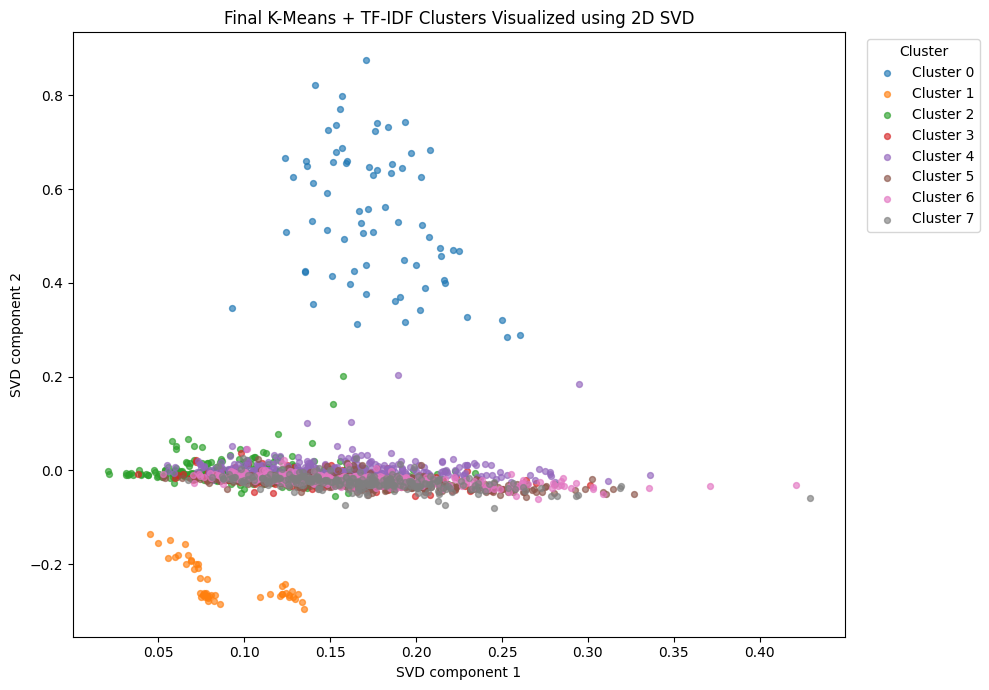

Explained variance in 2D projection: 0.0152


In [33]:
plot_clusters_2d(
    tfidf_matrix,
    articles["cluster_tfidf_final"],
    "Final K-Means + TF-IDF Clusters Visualized using 2D SVD"
)

### Manual Inspection of the Final Optimized K-Means + TF-IDF Model

In [34]:
final_cluster_column = "cluster_tfidf_final"
feature_names = tfidf_vectorizer.get_feature_names_out()
documents_to_show = 3

for cluster_id in sorted(articles[final_cluster_column].unique()):
    print(f"\n{'=' * 80}")
    print(f"Cluster {cluster_id}")

    cluster_mask = articles[final_cluster_column] == cluster_id
    cluster_positions = np.where(cluster_mask.to_numpy())[0]

    cluster_matrix = tfidf_matrix[cluster_positions]
    cluster_mean = cluster_matrix.mean(axis=0)
    cluster_mean = np.asarray(cluster_mean).ravel()

    top_indices = cluster_mean.argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_indices]

    print("Top terms:", ", ".join(top_words))
    print("Cluster size:", len(cluster_positions))

    centroid_similarities = cosine_similarity(
        cluster_matrix,
        cluster_mean.reshape(1, -1)
    ).ravel()

    representative_order = centroid_similarities.argsort()[::-1][
        :min(documents_to_show, len(cluster_positions))
    ]

    representative_positions = cluster_positions[representative_order]

    representative_docs = articles.iloc[representative_positions][
        ["doc_id", "cleaned_text"]
    ].copy()

    representative_docs["representativeness"] = centroid_similarities[
        representative_order
    ]

    representative_docs["cleaned_text"] = representative_docs[
        "cleaned_text"
    ].str.slice(0, 300)

    display(representative_docs)


Cluster 0
Top terms: cadr, dsl, jxp, chastiti, surrend, intellect, geb, skeptic, shame, gordon
Cluster size: 70


,doc_id,cleaned_text,representativeness
511,DOC_00512,want say gordon bank n jxp skeptic chastiti in...,0.936255
1194,DOC_01195,senil keratos noth liver gordon bank n jxp ske...,0.872509
1279,DOC_01280,diet evangelist good term fit atkin gordon ban...,0.851384



Cluster 1
Top terms: offer, item, deal, pickup, sale, bonu, coupon, http, fast, ref
Cluster size: 50


,doc_id,cleaned_text,representativeness
1649,DOC_01650,list id sale use tabl pickup antwerp ask price...,0.825945
878,DOC_00879,list id bike sale excel avail leuven ask cash ...,0.805206
1751,DOC_01752,list id sale almost new phone pickup ghent ask...,0.788789



Cluster 2
Top terms: one, like, would, edu, know, get, use, go, point, think
Cluster size: 551


...

,doc_id,cleaned_text,representativeness
229,DOC_00230,long leaf play short hand still expect score f...,0.463249
315,DOC_00316,deepli root rivalri ahem jokerit around sinc j...,0.456307
648,DOC_00649,nice tri deepak tough whaler squad clu fact le...,0.455799



Cluster 6
Top terms: space, orbit, launch, would, nasa, moon, think, fund, use, go
Cluster size: 333


,doc_id,cleaned_text,representativeness
1876,DOC_01877,ether implod earth core graviti paper describ ...,0.410004
1043,DOC_01044,follow thought meet hugh kelso bob lilli aid s...,0.401500
813,DOC_00814,ssf redesign let right time let step back cons...,0.400071



Cluster 7
Top terms: car, dealer, drive, engin, get, price, like, would, speed, look
Cluster size: 264


,doc_id,cleaned_text,representativeness
809,DOC_00810,nnnnnnnng thank play cannot agre believ put ni...,0.594786
726,DOC_00727,alreadi know call bank credit union financ com...,0.434108
761,DOC_00762,hi mayb someon help look buy nissan maximum gx...,0.428770


In [35]:
clusters_output = pd.DataFrame({
    "doc_id": articles["doc_id"],
    "cluster": articles["cluster_tfidf_final"]
})

clusters_output.to_csv("clusters.csv", index=False)

print("clusters.csv created successfully")
display(clusters_output.head())

clusters.csv created successfully


,doc_id,cluster
0,DOC_00001,2
1,DOC_00002,6
2,DOC_00003,6
3,DOC_00004,4
4,DOC_00005,3


## Task 3: Anomaly Detection

In [36]:
articles_anomaly = articles_raw.copy()

In [37]:
def structural_features(text):
    text = str(text)
    words = text.split()
    n_w = len(words)
    n_c = len(text)
    return pd.Series({
        "num_words":          np.log1p(n_w),
        "unique_ratio":       len(set(words)) / n_w if n_w > 0 else 0,
        "digit_ratio":        sum(c.isdigit() for c in text) / n_c if n_c > 0 else 0,
        "uppercase_ratio":    sum(c.isupper() for c in text) / n_c if n_c > 0 else 0,
        "punctuation_ratio":  sum(c in string.punctuation for c in text) / n_c if n_c > 0 else 0,
        "max_word_freq_ratio":max(Counter(words).values()) / n_w if n_w > 0 else 0,
        "newline_ratio":      text.count("\n") / n_c if n_c > 0 else 0,
    })

In [38]:
X = StandardScaler().fit_transform(
    articles_anomaly["text"].apply(structural_features).fillna(0)
)

iso = IsolationForest(n_estimators=100, contamination=50/len(articles_anomaly), random_state=42)
articles_anomaly["anomaly_score"] = -iso.fit(X).score_samples(X)

top_50 = articles_anomaly.sort_values("anomaly_score", ascending=False).head(50)

In [39]:
for _, row in top_50.iterrows():
    print("=" * 60)
    print("doc_id:", row["doc_id"], "| score:", round(row["anomaly_score"], 4))
    print(row["text"][:400])
    print()

top_50[["doc_id"]].to_csv("anomalies.csv", index=False)
print("Saved 50 anomalies")

doc_id: DOC_02077 | score: 0.787
Playoff leaders as of April 19, 1993 Player Team GP G A Pts +/- PIM M.Lemieux PIT 1 2 2 4 0 0 Juneau BOS 1 1 3 4 0 0 Noonan CHI 1 3 0 3 0 0 Mogilny BUF 1 2 1 3 0 0 Neely BOS 1 2 1 3 0 0 Brown STL 1 1 2 3 0 0 Jagr PIT 1 1 2 3 0 0 Oates BOS 1 0 3 3 0 0 Carson LA 1 2 0 2 0 0 Hunter WAS 1 2 0 2 0 0 Stevens NJ 1 2 0 2 0 0 Cullen TOR 1 1 1 2 0 0 Hull STL 1 1 1 2 0 0 Khristich WAS 1 1 1 2 0 0 Linden VAN 

doc_id: DOC_01716 | score: 0.724
Individual leaders by total points (Final standings) NOTE: Games played and points per games not accurate !! Player Team GP G A Pts ppg Prj PIM +/- M.Lemieux PIT 59 69 91 160 2.71 160 38 53 LaFontaine BUF 82 53 95 148 1.80 148 63 13 Oates BOS 83 45 97 142 1.71 142 32 12 Yzerman DET 83 58 79 137 1.65 137 44 33 Turgeon NYI 80 58 74 132 1.65 132 26 -2 Selanne WIN 82 76 56 132 1.61 132 45 6 Mogilny BU

doc_id: DOC_00105 | score: 0.7126
LISTING_ID_033 Selling my sofa, used, located near Hasselt, price 1200 EUR. cash on pickup. well